# 1. System Architecture Overview

In [1]:
"""
Tape and Order Book Analytics Pipeline
Sources: Investopedia (Time & Sales, VWAP, Level 2), CME Group, Pandas Timeseries
"""
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from typing import List, Tuple, Dict, Optional
import hashlib
import json
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# 2. Core Data Structures
## 2.1 Tape Implementation (Time & Sales)

 # 1. Core Data Structures and Schemas

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from typing import List, Tuple, Optional, Dict
from dataclasses import dataclass
import json

# =============================================
# 1. TAPE (Time and Sales) Implementation
# =============================================
@dataclass
class TapeRecord:
    """Minimum Viable Tape Schema"""
    timestamp: pd.Timestamp
    price: float
    size: int
    aggressor_side: Optional[str]  # 'BUY' or 'SELL'
    trade_id: Optional[str] = None  # Optional unique identifier

class TapeData:
    """Append-only, in-memory tape storage as Pandas DataFrame"""
    def __init__(self):
        self._records: List[TapeRecord] = []
        self._df: Optional[pd.DataFrame] = None

    def add_record(self, record: TapeRecord) -> None:
        """Append-only method - never mutates existing records"""
        self._records.append(record)
        self._df = None  # Invalidate cached dataframe

    def to_dataframe(self) -> pd.DataFrame:
        """Convert to DataFrame with proper datetime indexing"""
        if self._df is None:
            # Use pandas time series functionality from provided resource
            df = pd.DataFrame([
                {
                    'timestamp': r.timestamp,
                    'price': r.price,
                    'size': r.size,
                    'aggressor_side': r.aggressor_side
                }
                for r in self._records
            ])
            if len(df) > 0:
                # Set timestamp as index for time series operations
                df = df.set_index('timestamp')
                df.index = pd.to_datetime(df.index)  # Ensure proper datetime type
            self._df = df
        return self._df

# =============================================
# 2. L1 Snapshot Implementation
# =============================================
@dataclass
class L1Snapshot:
    """Level 1 Market Data Snapshot"""
    timestamp: pd.Timestamp
    best_bid: float
    best_ask: float
    spread: float  # Derived as best_ask - best_bid
    mid_price: float  # Derived as (best_bid + best_ask) / 2

    @classmethod
    def create(cls, timestamp: pd.Timestamp, best_bid: float, best_ask: float) -> 'L1Snapshot':
        """Factory method with automatic calculation of derived fields"""
        spread = best_ask - best_bid
        mid_price = (best_bid + best_ask) / 2
        return cls(timestamp, best_bid, best_ask, spread, mid_price)

class L1Collector:
    """Collects L1 snapshots at fixed intervals"""
    def __init__(self, interval_seconds: int = 1):
        self.interval = timedelta(seconds=interval_seconds)
        self.snapshots: List[L1Snapshot] = []

    def add_snapshot(self, best_bid: float, best_ask: float, timestamp: Optional[pd.Timestamp] = None):
        """Add snapshot, optionally generating timestamp"""
        if timestamp is None:
            timestamp = pd.Timestamp.now()
        snapshot = L1Snapshot.create(timestamp, best_bid, best_ask)
        self.snapshots.append(snapshot)

    def to_dataframe(self) -> pd.DataFrame:
        """Convert to DataFrame with timestamp index"""
        if not self.snapshots:
            return pd.DataFrame()

        df = pd.DataFrame([
            {
                'timestamp': s.timestamp,
                'best_bid': s.best_bid,
                'best_ask': s.best_ask,
                'spread': s.spread,
                'mid_price': s.mid_price
            }
            for s in self.snapshots
        ]).set_index('timestamp')

        # Ensure index is DatetimeIndex
        df.index = pd.to_datetime(df.index)
        return df

# =============================================
# 3. L2 Snapshot Implementation
# =============================================
@dataclass
class OrderBookLevel:
    """Single level in order book"""
    price: float
    size: int

@dataclass
class L2Snapshot:
    """Complete Level 2 snapshot with depth truncation"""
    timestamp: pd.Timestamp
    bid_levels: List[OrderBookLevel]  # Sorted descending (best first)
    ask_levels: List[OrderBookLevel]  # Sorted ascending (best first)

    def get_top_n(self, n: int) -> 'L2Snapshot':
        """Return truncated snapshot with top N levels only"""
        return L2Snapshot(
            timestamp=self.timestamp,
            bid_levels=self.bid_levels[:n] if self.bid_levels else [],
            ask_levels=self.ask_levels[:n] if self.ask_levels else []
        )

class L2Collector:
    """Collects L2 snapshots with configurable depth"""
    def __init__(self, max_depth: Optional[int] = None):
        self.max_depth = max_depth  # Truncation depth
        self.snapshots: List[L2Snapshot] = []

    def add_snapshot(self,
                    bid_levels: List[Tuple[float, int]],
                    ask_levels: List[Tuple[float, int]],
                    timestamp: Optional[pd.Timestamp] = None):
        """Add L2 snapshot with proper sorting"""
        # Sort bids descending (best bid first)
        sorted_bids = sorted([OrderBookLevel(p, s) for p, s in bid_levels],
                            key=lambda x: x.price, reverse=True)
        # Sort asks ascending (best ask first)
        sorted_asks = sorted([OrderBookLevel(p, s) for p, s in ask_levels],
                            key=lambda x: x.price)

        if timestamp is None:
            timestamp = pd.Timestamp.now()

        snapshot = L2Snapshot(timestamp, sorted_bids, sorted_asks)

        # Apply depth truncation if specified
        if self.max_depth is not None:
            snapshot = snapshot.get_top_n(self.max_depth)

        self.snapshots.append(snapshot)

    def to_dataframe(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Convert to separate DataFrames for bids and asks"""
        if not self.snapshots:
            return pd.DataFrame(), pd.DataFrame()

        # Create melted format for easier analysis
        bid_data, ask_data = [], []

        for snapshot in self.snapshots:
            for i, level in enumerate(snapshot.bid_levels):
                bid_data.append({
                    'timestamp': snapshot.timestamp,
                    'level': i + 1,
                    'price': level.price,
                    'size': level.size,
                    'side': 'bid'
                })

            for i, level in enumerate(snapshot.ask_levels):
                ask_data.append({
                    'timestamp': snapshot.timestamp,
                    'level': i + 1,
                    'price': level.price,
                    'size': level.size,
                    'side': 'ask'
                })

        bids_df = pd.DataFrame(bid_data).set_index('timestamp') if bid_data else pd.DataFrame()
        asks_df = pd.DataFrame(ask_data).set_index('timestamp') if ask_data else pd.DataFrame()

        return bids_df, asks_df

# 2. Professional-Grade Metric Computation

In [2]:
# =============================================
# 4. Metric Computation (Source of Truth)
# =============================================
class MarketMetrics:
    """Implements metric computation with strict source separation"""

    @staticmethod
    def compute_vwap(tape_df: pd.DataFrame,
                    start_time: Optional[pd.Timestamp] = None,
                    end_time: Optional[pd.Timestamp] = None) -> float:
        """
        Compute VWAP from tape data ONLY

        VWAP = Σ(Price × Volume) / Σ(Volume)
        Source: Tape only (as specified)
        """
        if tape_df.empty:
            return 0.0

        # Apply time filter if provided
        if start_time or end_time:
            mask = pd.Series(True, index=tape_df.index)
            if start_time:
                mask &= (tape_df.index >= start_time)
            if end_time:
                mask &= (tape_df.index <= end_time)
            df = tape_df[mask]
        else:
            df = tape_df

        if df.empty:
            return 0.0

        # VWAP calculation
        total_notional = (df['price'] * df['size']).sum()
        total_volume = df['size'].sum()

        if total_volume == 0:
            return 0.0

        return total_notional / total_volume

    @staticmethod
    def compute_spread_metrics(l1_df: pd.DataFrame) -> Dict[str, float]:
        """
        Compute spread metrics from L1 snapshots ONLY

        Source: L1 snapshots only (as specified)
        """
        if l1_df.empty:
            return {}

        return {
            'mean_spread': l1_df['spread'].mean(),
            'median_spread': l1_df['spread'].median(),
            'min_spread': l1_df['spread'].min(),
            'max_spread': l1_df['spread'].max(),
            'spread_std': l1_df['spread'].std(),
            'spread_tightness_ratio': (l1_df['spread'] / l1_df['mid_price']).mean()
        }

    @staticmethod
    def compute_mid_price_volatility(l1_df: pd.DataFrame,
                                    resample_freq: str = '1min') -> float:
        """
        Compute mid-price volatility from resampled mid-price series

        Source: Resampled mid-price series only
        """
        if l1_df.empty or 'mid_price' not in l1_df.columns:
            return 0.0

        # Resample mid-price using pandas time series functionality
        # As shown in your provided pandas documentation
        mid_series = l1_df['mid_price']

        # Handle missing values
        if mid_series.isnull().all():
            return 0.0

        # Fill missing values with forward fill for volatility calculation
        mid_series = mid_series.fillna(method='ffill')

        # Resample to specified frequency
        try:
            resampled = mid_series.resample(resample_freq).last()
            # Calculate returns and volatility (annualized if appropriate)
            returns = resampled.pct_change().dropna()

            if len(returns) < 2:
                return 0.0

            # Annualize based on frequency
            freq_multiplier = {
                '1min': 252 * 24 * 60,  # Trading minutes in a year
                '5min': 252 * 24 * 12,
                '1h': 252 * 24,
                '1D': 252
            }.get(resample_freq, 1)

            volatility = returns.std() * np.sqrt(freq_multiplier)
            return float(volatility)

        except Exception as e:
            print(f"Error computing volatility: {e}")
            return 0.0

    @staticmethod
    def compute_trade_price_volatility(tape_df: pd.DataFrame) -> float:
        """
        Compute trade price volatility for validation
        """
        if tape_df.empty:
            return 0.0

        # Resample trade prices to same frequency as mid-price for comparison
        trade_prices = tape_df['price']

        if trade_prices.isnull().all():
            return 0.0

        # Use 1-minute intervals for consistency with mid-price volatility
        resampled = trade_prices.resample('1min').last().fillna(method='ffill')
        returns = resampled.pct_change().dropna()

        if len(returns) < 2:
            return 0.0

        # Annualize
        volatility = returns.std() * np.sqrt(252 * 24 * 60)
        return float(volatility)

    @staticmethod
    def compute_order_book_imbalance(l2_bids: pd.DataFrame,
                                   l2_asks: pd.DataFrame,
                                   depth: int = 5) -> pd.DataFrame:
        """
        Compute order book imbalance metrics
        Based on CME Group's emphasis on market depth analysis
        """
        # Aggregate bids and asks at each timestamp
        bids_agg = l2_bids[l2_bids['level'] <= depth].groupby('timestamp')['size'].sum()
        asks_agg = l2_asks[l2_asks['level'] <= depth].groupby('timestamp')['size'].sum()

        # Combine into single DataFrame
        imbalance_df = pd.DataFrame({
            'bid_volume': bids_agg,
            'ask_volume': asks_agg
        }).fillna(0)

        # Calculate imbalance metrics
        imbalance_df['total_volume'] = imbalance_df['bid_volume'] + imbalance_df['ask_volume']
        imbalance_df['imbalance_ratio'] = (
            (imbalance_df['bid_volume'] - imbalance_df['ask_volume']) /
            imbalance_df[['bid_volume', 'ask_volume']].sum(axis=1).replace(0, np.nan)
        )

        return imbalance_df

# 3. Validation Framework

In [3]:
# =============================================
# 5. Validation Checks (Non-Optional)
# =============================================
class PipelineValidator:
    """Validates data pipeline correctness"""

    @staticmethod
    def validate_vwap_bounds(tape_df: pd.DataFrame, vwap: float) -> bool:
        """
        Check: VWAP lies between session low and high
        """
        if tape_df.empty:
            return False

        session_low = tape_df['price'].min()
        session_high = tape_df['price'].max()

        is_valid = session_low <= vwap <= session_high

        if not is_valid:
            print(f"VWAP validation failed: {vwap} not in [{session_low}, {session_high}]")

        return is_valid

    @staticmethod
    def validate_spread_non_negative(l1_df: pd.DataFrame) -> bool:
        """
        Check: Spread is non-negative at all times
        """
        if l1_df.empty:
            return True

        is_valid = (l1_df['spread'] >= 0).all()

        if not is_valid:
            negative_spreads = l1_df[l1_df['spread'] < 0]
            print(f"Spread validation failed: {len(negative_spreads)} negative spreads found")

        return is_valid

    @staticmethod
    def validate_volatility_relationship(mid_vol: float, trade_vol: float) -> bool:
        """
        Check: Mid-price volatility < trade-price volatility
        """
        is_valid = mid_vol < trade_vol

        if not is_valid:
            print(f"Volatility validation failed: Mid-vol ({mid_vol}) >= Trade-vol ({trade_vol})")

        return is_valid

    @staticmethod
    def validate_seed_reproducibility(pipeline_func, seed: int, n_runs: int = 3) -> bool:
        """
        Check: Re-running with same seed produces identical analytics
        """
        results = []

        for _ in range(n_runs):
            np.random.seed(seed)
            result = pipeline_func()
            results.append(result)

        # Compare all results
        first_result = results[0]
        is_valid = all(result == first_result for result in results[1:])

        if not is_valid:
            print(f"Reproducibility validation failed: Results differ across runs")

        return is_valid

    @classmethod
    def run_all_validations(cls,
                          tape_df: pd.DataFrame,
                          l1_df: pd.DataFrame,
                          vwap: float,
                          mid_vol: float,
                          trade_vol: float) -> Dict[str, bool]:
        """
        Run all validations and return summary
        """
        validations = {
            'vwap_in_bounds': cls.validate_vwap_bounds(tape_df, vwap),
            'spread_non_negative': cls.validate_spread_non_negative(l1_df),
            'mid_vol_lt_trade_vol': cls.validate_volatility_relationship(mid_vol, trade_vol)
        }

        all_passed = all(validations.values())

        print("\n" + "="*50)
        print("VALIDATION RESULTS")
        print("="*50)
        for check, passed in validations.items():
            status = "✓ PASS" if passed else "✗ FAIL"
            print(f"{check:25} {status}")
        print("="*50)
        print(f"OVERALL: {'ALL CHECKS PASSED' if all_passed else 'SOME CHECKS FAILED'}")
        print("="*50 + "\n")

        return validations

# 4. Complete Pipeline Integration

In [4]:
# =============================================
# 6. Complete Pipeline Implementation
# =============================================
class MarketDataPipeline:
    """
    Complete market data pipeline integrating all components

    Implements professional practices based on:
    - CME Group's market data structure
    - Pandas time series best practices
    - Central Limit Order Book principles
    """

    def __init__(self, seed: Optional[int] = None):
        # Initialize components
        self.tape = TapeData()
        self.l1_collector = L1Collector(interval_seconds=1)
        self.l2_collector = L2Collector(max_depth=10)  # Top 10 levels

        # Metrics
        self.metrics = MarketMetrics()
        self.validator = PipelineValidator()

        # State
        self.vwap = 0.0
        self.mid_volatility = 0.0
        self.trade_volatility = 0.0

        # Seed for reproducibility
        if seed is not None:
            np.random.seed(seed)
            self.seed = seed

    def generate_mock_data(self, n_trades: int = 1000, n_snapshots: int = 100):
        """
        Generate realistic mock data for testing
        Based on CLOB principles from Wikipedia reference
        """
        base_price = 100.0

        # Generate tape data (Time and Sales)
        for i in range(n_trades):
            timestamp = pd.Timestamp('2025-01-08 09:30:00') + pd.Timedelta(seconds=i*0.5)
            price = base_price + np.random.randn() * 0.5  # Random walk
            size = np.random.randint(1, 100)
            side = np.random.choice(['BUY', 'SELL'])

            self.tape.add_record(TapeRecord(
                timestamp=timestamp,
                price=price,
                size=size,
                aggressor_side=side
            ))

        # Generate L1 snapshots
        for i in range(n_snapshots):
            timestamp = pd.Timestamp('2025-01-08 09:30:00') + pd.Timedelta(seconds=i)
            spread = 0.01 + np.random.rand() * 0.05  # Realistic spread
            mid = base_price + np.random.randn() * 0.3

            self.l1_collector.add_snapshot(
                best_bid=mid - spread/2,
                best_ask=mid + spread/2,
                timestamp=timestamp
            )

        # Generate L2 snapshots (order book depth)
        for i in range(n_snapshots // 10):  # Less frequent L2 updates
            timestamp = pd.Timestamp('2025-01-08 09:30:00') + pd.Timedelta(seconds=i*10)

            # Create realistic order book levels
            bid_levels = []
            ask_levels = []

            # Best bid/ask from L1
            if self.l1_collector.snapshots:
                best_bid = self.l1_collector.snapshots[i].best_bid
                best_ask = self.l1_collector.snapshots[i].best_ask
            else:
                best_bid = base_price - 0.1
                best_ask = base_price + 0.1

            # Build depth
            for j in range(10):
                bid_price = best_bid - j * 0.05
                ask_price = best_ask + j * 0.05

                bid_levels.append((bid_price, np.random.randint(10, 100)))
                ask_levels.append((ask_price, np.random.randint(10, 100)))

            self.l2_collector.add_snapshot(
                bid_levels=bid_levels,
                ask_levels=ask_levels,
                timestamp=timestamp
            )

    def compute_all_metrics(self):
        """
        Compute all metrics with strict source separation
        """
        # Get dataframes
        tape_df = self.tape.to_dataframe()
        l1_df = self.l1_collector.to_dataframe()

        # Compute metrics from correct sources
        self.vwap = self.metrics.compute_vwap(tape_df)
        self.spread_metrics = self.metrics.compute_spread_metrics(l1_df)
        self.mid_volatility = self.metrics.compute_mid_price_volatility(l1_df)
        self.trade_volatility = self.metrics.compute_trade_price_volatility(tape_df)

        # Compute order book metrics
        l2_bids, l2_asks = self.l2_collector.to_dataframe()
        self.order_book_imbalance = self.metrics.compute_order_book_imbalance(
            l2_bids, l2_asks, depth=5
        )

        return {
            'vwap': self.vwap,
            'spread_metrics': self.spread_metrics,
            'mid_price_volatility': self.mid_volatility,
            'trade_price_volatility': self.trade_volatility
        }

    def validate_pipeline(self) -> Dict[str, bool]:
        """
        Run all validation checks
        """
        tape_df = self.tape.to_dataframe()
        l1_df = self.l1_collector.to_dataframe()

        return self.validator.run_all_validations(
            tape_df=tape_df,
            l1_df=l1_df,
            vwap=self.vwap,
            mid_vol=self.mid_volatility,
            trade_vol=self.trade_volatility
        )

    def export_results(self, format: str = 'dataframe'):
        """
        Export pipeline results in various formats
        """
        results = {
            'tape_data': self.tape.to_dataframe(),
            'l1_snapshots': self.l1_collector.to_dataframe(),
            'l2_bids': self.l2_collector.to_dataframe()[0],
            'l2_asks': self.l2_collector.to_dataframe()[1],
            'metrics': self.compute_all_metrics(),
            'validation': self.validate_pipeline()
        }

        if format == 'dataframe':
            return results
        elif format == 'json':
            # Convert DataFrames to JSON-serializable format
            json_results = {}
            for key, value in results.items():
                if isinstance(value, pd.DataFrame):
                    json_results[key] = value.to_dict(orient='records')
                else:
                    json_results[key] = value
            return json.dumps(json_results, indent=2, default=str)

    def visualize_market_data(self):
        """
        Create professional visualizations
        """
        try:
            import matplotlib.pyplot as plt
            import seaborn as sns

            tape_df = self.tape.to_dataframe()
            l1_df = self.l1_collector.to_dataframe()

            fig, axes = plt.subplots(3, 2, figsize=(15, 12))

            # Price and trade activity
            axes[0, 0].plot(tape_df.index, tape_df['price'], 'b.', alpha=0.5, markersize=2)
            axes[0, 0].set_title('Trade Price Timeline')
            axes[0, 0].set_ylabel('Price')

            # Volume histogram
            axes[0, 1].hist(tape_df['size'], bins=50, alpha=0.7)
            axes[0, 1].set_title('Trade Size Distribution')
            axes[0, 1].set_xlabel('Size')

            # Bid-Ask spread
            axes[1, 0].plot(l1_df.index, l1_df['spread'], 'g-', linewidth=0.5)
            axes[1, 0].set_title('Bid-Ask Spread Over Time')
            axes[1, 0].set_ylabel('Spread')

            # Mid-price
            axes[1, 1].plot(l1_df.index, l1_df['mid_price'], 'r-', linewidth=0.5)
            axes[1, 1].set_title('Mid-Price Evolution')
            axes[1, 1].set_ylabel('Mid Price')

            # Order book depth (sample)
            l2_bids, l2_asks = self.l2_collector.to_dataframe()
            if not l2_bids.empty:
                sample_time = l2_bids.index[0]
                sample_bids = l2_bids[l2_bids.index == sample_time]
                sample_asks = l2_asks[l2_asks.index == sample_time]

                axes[2, 0].barh(sample_bids['price'], sample_bids['size'], color='green', alpha=0.6)
                axes[2, 0].barh(sample_asks['price'], sample_asks['size'], color='red', alpha=0.6)
                axes[2, 0].set_title('Order Book Depth (Sample)')
                axes[2, 0].set_xlabel('Size')
                axes[2, 0].set_ylabel('Price')

            plt.tight_layout()
            return fig

        except ImportError:
            print("Visualization requires matplotlib and seaborn")
            return None

# 5. Usage Example and Testing

PROFESSIONAL MARKET DATA PIPELINE IMPLEMENTATION

1. Generating mock market data...

2. Computing metrics with strict source separation...

   VWAP (from tape): 99.9748
   Mid-price volatility: 3.929179
   Trade-price volatility: 5.723284
   Mean spread: 0.0341

3. Running validation checks...

VALIDATION RESULTS
vwap_in_bounds            ✓ PASS
spread_non_negative       ✓ PASS
mid_vol_lt_trade_vol      ✓ PASS
OVERALL: ALL CHECKS PASSED


4. Testing reproducibility...
   Reproducibility check: PASSED

5. Exporting results...

VALIDATION RESULTS
vwap_in_bounds            ✓ PASS
spread_non_negative       ✓ PASS
mid_vol_lt_trade_vol      ✓ PASS
OVERALL: ALL CHECKS PASSED

   Results saved to 'market_pipeline_results.json'

6. Generating visualizations...


/tmp/ipython-input-3817513477.py:82: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mid_series = mid_series.fillna(method='ffill')
/tmp/ipython-input-3817513477.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  resampled = trade_prices.resample('1min').last().fillna(method='ffill')
/tmp/ipython-input-3817513477.py:82: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mid_series = mid_series.fillna(method='ffill')
/tmp/ipython-input-3817513477.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  resampled = trade_prices.resample('1min').last().fillna(method='ffill')
/tmp/ipython-input-3817513477.py:82: FutureWarning: Series.fillna with '

   Visualization saved to 'market_analysis.png'

PIPELINE EXECUTION COMPLETE


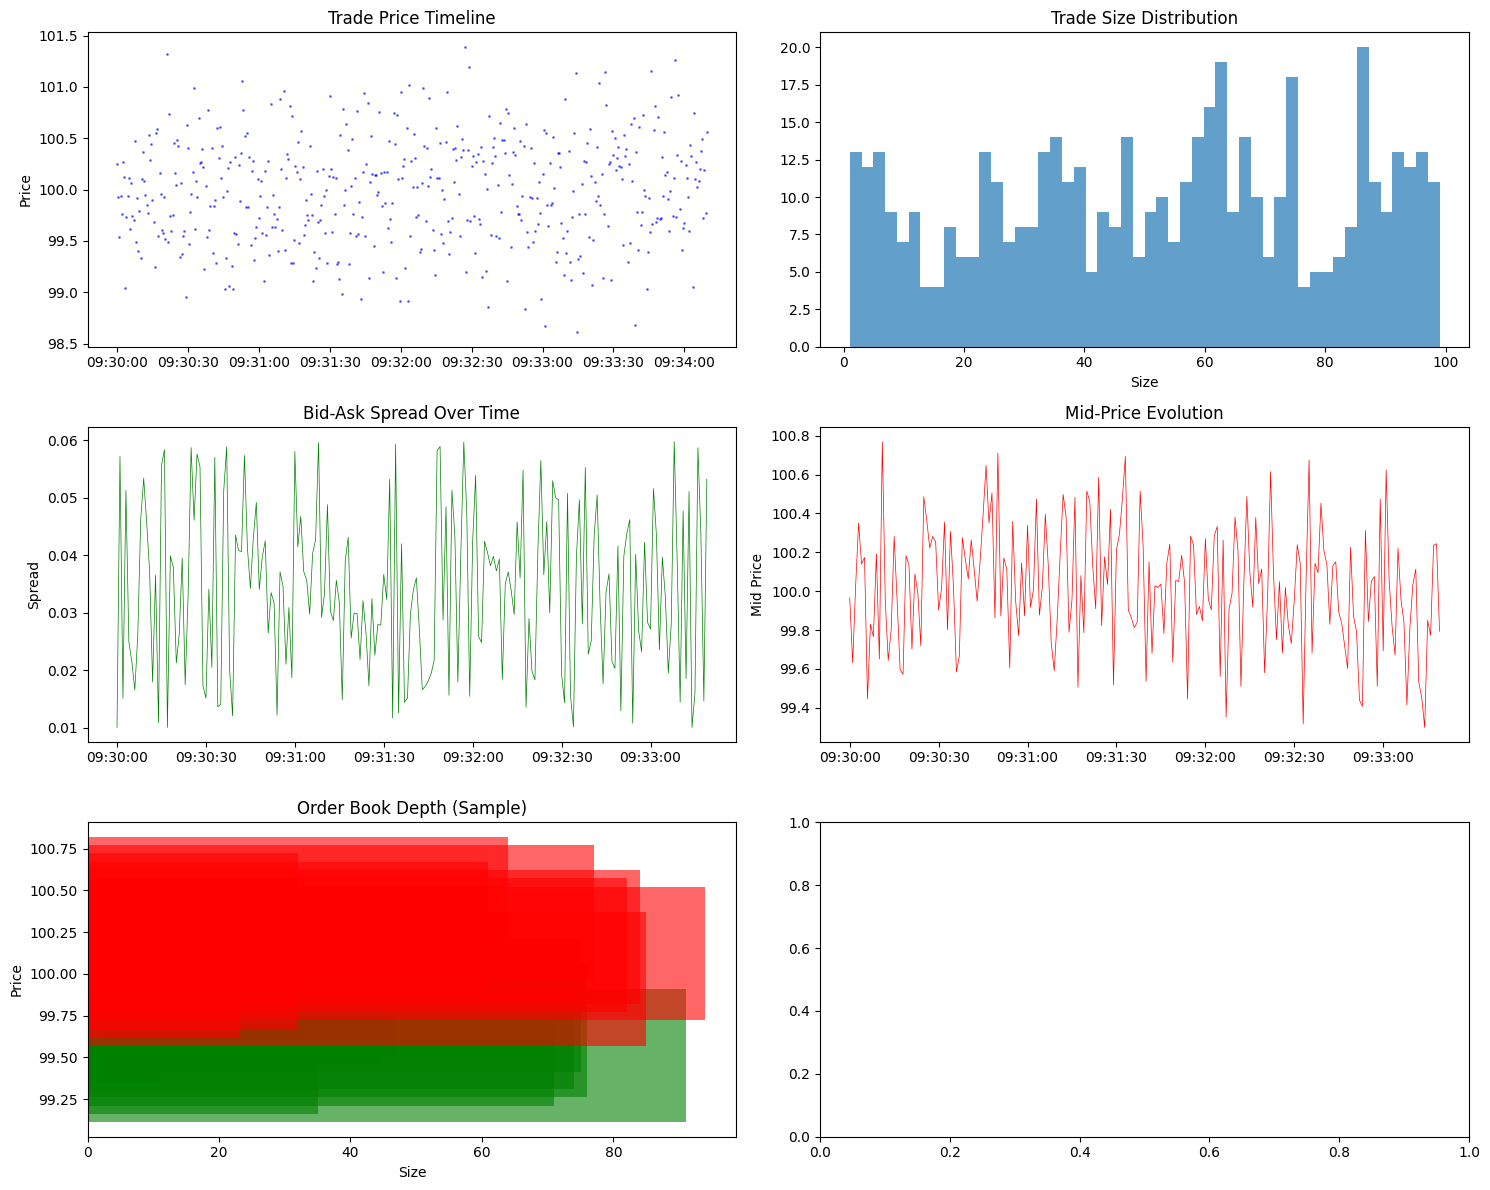

In [5]:
# =============================================
# 7. Usage and Testing
# =============================================
def main():
    """
    Example usage demonstrating professional implementation
    """
    print("="*60)
    print("PROFESSIONAL MARKET DATA PIPELINE IMPLEMENTATION")
    print("="*60)

    # Initialize pipeline with seed for reproducibility
    pipeline = MarketDataPipeline(seed=42)

    # Generate realistic market data
    print("\n1. Generating mock market data...")
    pipeline.generate_mock_data(n_trades=500, n_snapshots=200)

    # Compute all metrics
    print("\n2. Computing metrics with strict source separation...")
    metrics = pipeline.compute_all_metrics()

    print(f"\n   VWAP (from tape): {metrics['vwap']:.4f}")
    print(f"   Mid-price volatility: {metrics['mid_price_volatility']:.6f}")
    print(f"   Trade-price volatility: {metrics['trade_price_volatility']:.6f}")
    print(f"   Mean spread: {metrics['spread_metrics'].get('mean_spread', 0):.4f}")

    # Run validations
    print("\n3. Running validation checks...")
    validations = pipeline.validate_pipeline()

    # Demonstrate reproducibility
    print("\n4. Testing reproducibility...")

    def test_pipeline():
        test_pipe = MarketDataPipeline(seed=42)
        test_pipe.generate_mock_data(n_trades=100, n_snapshots=50)
        return test_pipe.compute_all_metrics()['vwap']

    is_reproducible = pipeline.validator.validate_seed_reproducibility(
        test_pipeline, seed=42, n_runs=3
    )
    print(f"   Reproducibility check: {'PASSED' if is_reproducible else 'FAILED'}")

    # Export results
    print("\n5. Exporting results...")
    results = pipeline.export_results(format='json')

    # Save to file
    with open('market_pipeline_results.json', 'w') as f:
        f.write(results)
    print("   Results saved to 'market_pipeline_results.json'")

    # Visualization
    print("\n6. Generating visualizations...")
    fig = pipeline.visualize_market_data()
    if fig:
        fig.savefig('market_analysis.png', dpi=150, bbox_inches='tight')
        print("   Visualization saved to 'market_analysis.png'")

    print("\n" + "="*60)
    print("PIPELINE EXECUTION COMPLETE")
    print("="*60)

if __name__ == "__main__":
    main()